# BTCUSDC vs ONDOUSDC Pairs Correlation

This notebook checks whether `BTCUSDC` is a useful short-horizon price predictor for `ONDOUSDC` on the shared sample from `20260226`, `20260227`, and `20260228`.

The notebook stays thin: it loads cached top-of-book tables, aligns both symbols on a shared 500ms clock grid, and measures how the relationship changes as BTC is shifted ahead of ONDO.


## What We Are Testing

We care about two different questions:

- **co-movement**: do BTC and ONDO move together at the same timestamp?
- **predictive power**: does a BTC move at time `t` help explain an ONDO move at time `t + lag`?

A high same-time correlation is not the same as a useful predictor. This notebook keeps those two ideas separate, and the 500ms grid lets us compare 500ms, 1s, and 2s leads on the same clock base.


In [1]:
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def load_notebook_utils(start: Path | None = None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        utils_path = candidate / "notebooks" / "notebook_utils.py"
        if utils_path.is_file():
            spec = importlib.util.spec_from_file_location("notebook_utils", utils_path)
            if spec is None or spec.loader is None:
                raise ImportError(f"Could not load notebook utilities from {utils_path}")
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            return module
    raise FileNotFoundError("Could not locate notebooks/notebook_utils.py")


notebook_utils = load_notebook_utils()
PROJECT_ROOT = notebook_utils.bootstrap_backtester_path()

from stats.notebook import load_orderflow_day

EXCHANGE = "binance"
BTC_SYMBOL = "BTCUSDC"
ONDO_SYMBOL = "ONDOUSDC"
DAYS = ["20260226", "20260227", "20260228"]
GRID_FREQ = "500ms"
LAGS_S = [0, 1, 2, 4, 10, 20, 60, 600]
REPLAY_ON_GAP = "skip-segment"

make_clock_grid = notebook_utils.make_clock_grid


In [2]:
def build_day_pair_frame(day: str, *, grid_freq: str = GRID_FREQ) -> pd.DataFrame:
    """Return a shared clock-time grid for BTCUSDC and ONDOUSDC."""
    _, _, btc_top, _ = load_orderflow_day(
        day=day,
        symbol=BTC_SYMBOL,
        exchange=EXCHANGE,
        replay_on_gap=REPLAY_ON_GAP,
    )
    _, _, ondo_top, _ = load_orderflow_day(
        day=day,
        symbol=ONDO_SYMBOL,
        exchange=EXCHANGE,
        replay_on_gap=REPLAY_ON_GAP,
    )

    btc_grid = make_clock_grid(btc_top, freq=grid_freq)[["ts", "log_mid"]].rename(columns={"log_mid": "btc_log_mid"})
    ondo_grid = make_clock_grid(ondo_top, freq=grid_freq)[["ts", "log_mid"]].rename(columns={"log_mid": "ondo_log_mid"})

    start = max(btc_grid["ts"].min(), ondo_grid["ts"].min())
    end = min(btc_grid["ts"].max(), ondo_grid["ts"].max())
    common = pd.DataFrame({"ts": pd.date_range(start, end, freq=grid_freq, tz="UTC")})
    common = pd.merge_asof(common, btc_grid, on="ts", direction="backward")
    common = pd.merge_asof(common, ondo_grid, on="ts", direction="backward")
    common = common.dropna(subset=["btc_log_mid", "ondo_log_mid"]).copy()
    common["btc_ret"] = common["btc_log_mid"].diff()
    common["ondo_ret"] = common["ondo_log_mid"].diff()
    common = common.dropna(subset=["btc_ret", "ondo_ret"]).reset_index(drop=True)
    common["day"] = day
    return common


def lag_pair_sample(frame: pd.DataFrame, lag_s: int) -> pd.DataFrame:
    out = pd.DataFrame(
        {
            "btc_ret_lagged": frame["btc_ret"].shift(lag_s),
            "ondo_ret": frame["ondo_ret"],
            "day": frame["day"],
        }
    )
    return out.dropna(subset=["btc_ret_lagged", "ondo_ret"]).reset_index(drop=True)


def summarize_pair_sample(pair: pd.DataFrame, lag_s: int) -> pd.Series:
    if pair.empty:
        return pd.Series(
            {
                "lag_s": lag_s,
                "pearson": np.nan,
                "spearman": np.nan,
                "sign_hit": np.nan,
                "beta": np.nan,
                "r2": np.nan,
                "n": 0,
            }
        )

    x = pair["btc_ret_lagged"].to_numpy(dtype=float)
    y = pair["ondo_ret"].to_numpy(dtype=float)
    beta = float(np.polyfit(x, y, 1)[0]) if len(pair) > 1 else np.nan
    yhat = beta * x
    sse = float(np.sum((y - yhat) ** 2))
    sst = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - sse / sst if sst > 0 else np.nan

    return pd.Series(
        {
            "lag_s": lag_s,
            "pearson": float(pair["btc_ret_lagged"].corr(pair["ondo_ret"])),
            "spearman": float(pair["btc_ret_lagged"].corr(pair["ondo_ret"], method="spearman")),
            "sign_hit": float((np.sign(x) == np.sign(y)).mean()),
            "beta": beta,
            "r2": r2,
            "n": int(len(pair)),
        }
    )


def summarize_lag(frame: pd.DataFrame, lag_s: int) -> pd.Series:
    return summarize_pair_sample(lag_pair_sample(frame, lag_s), lag_s)


def summarize_frame(frame: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame([summarize_lag(frame, lag_s) for lag_s in LAGS_S])


def build_aggregate_pair_sample(day_frames: dict[str, pd.DataFrame], lag_s: int) -> pd.DataFrame:
    parts = [lag_pair_sample(frame, lag_s) for frame in day_frames.values()]
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=["btc_ret_lagged", "ondo_ret", "day"])


In [3]:
day_frames = {day: build_day_pair_frame(day) for day in DAYS}
day_sizes = pd.DataFrame(
    {
        "day": list(day_frames.keys()),
        "rows": [len(frame) for frame in day_frames.values()],
        "start_utc": [frame["ts"].min() for frame in day_frames.values()],
        "end_utc": [frame["ts"].max() for frame in day_frames.values()],
    }
)

display(day_sizes)


,day,rows,start_utc,end_utc
0,20260226,160180,2026-02-26 01:00:11+00:00,2026-02-26 23:15:00.500000+00:00
1,20260227,160173,2026-02-27 01:00:14.500000+00:00,2026-02-27 23:15:00.500000+00:00
2,20260228,160168,2026-02-28 01:00:17+00:00,2026-02-28 23:15:00.500000+00:00


In [4]:
daily_summary = pd.concat(
    [summarize_frame(frame).assign(day=day) for day, frame in day_frames.items()],
    ignore_index=True,
)

daily_summary = daily_summary[["day", "lag_s", "pearson", "spearman", "sign_hit", "beta", "r2", "n"]]
display(daily_summary)

same_time = daily_summary[daily_summary["lag_s"] == 0][["day", "pearson", "sign_hit", "r2", "n"]].rename(
    columns={"pearson": "same_time_pearson", "sign_hit": "same_time_sign_hit", "r2": "same_time_r2"}
)
lead_500ms = daily_summary[daily_summary["lag_s"] == 1][["day", "pearson", "sign_hit", "r2", "n"]].rename(
    columns={"pearson": "lead_500ms_pearson", "sign_hit": "lead_500ms_sign_hit", "r2": "lead_500ms_r2"}
)
lead_1s = daily_summary[daily_summary["lag_s"] == 2][["day", "pearson", "sign_hit", "r2", "n"]].rename(
    columns={"pearson": "lead_1s_pearson", "sign_hit": "lead_1s_sign_hit", "r2": "lead_1s_r2"}
)

day_comparison = same_time.merge(lead_500ms, on="day", how="inner").merge(lead_1s, on="day", how="inner")
display(day_comparison)


,day,lag_s,pearson,spearman,sign_hit,beta,r2,n
0,20260226,0.0,0.396102,0.304147,0.737801,0.728816,1.568958e-01,160180.0
1,20260226,1.0,0.093798,0.070194,0.688598,0.172586,8.795780e-03,160179.0
2,20260226,2.0,0.047739,0.033976,0.680599,0.087835,2.276422e-03,160178.0
3,20260226,4.0,0.021194,0.015643,0.678547,0.038994,4.464808e-04,160176.0
4,20260226,10.0,0.006367,0.002977,0.675819,0.011714,3.785352e-05,160170.0
5,20260226,20.0,0.011046,0.005566,0.676698,0.020322,1.193474e-04,160160.0
6,20260226,60.0,0.004397,0.004654,0.674681,0.008088,1.660584e-05,160120.0
7,20260226,600.0,0.002148,0.001823,0.673155,0.003944,1.068849e-06,159580.0
8,20260227,0.0,0.323719,0.249148,0.739831,0.562839,1.047927e-01,160173.0
9,20260227,1.0,0.068934,0.051423,0.700403,0.119853,4.749232e-03,160172.0


,day,same_time_pearson,same_time_sign_hit,same_time_r2,n_x,lead_500ms_pearson,lead_500ms_sign_hit,lead_500ms_r2,n_y,lead_1s_pearson,lead_1s_sign_hit,lead_1s_r2,n
0,20260226,0.396102,0.737801,0.156896,160180.0,0.093798,0.688598,0.008796,160179.0,0.047739,0.680599,0.002276,160178.0
1,20260227,0.323719,0.739831,0.104793,160173.0,0.068934,0.700403,0.004749,160172.0,0.036704,0.695881,0.001344,160171.0
2,20260228,0.403342,0.755863,0.162684,160168.0,0.094057,0.707586,0.008846,160167.0,0.035612,0.701466,0.001268,160166.0


In [5]:
aggregate_summary = pd.concat(
    [summarize_pair_sample(build_aggregate_pair_sample(day_frames, lag_s), lag_s).to_frame().T for lag_s in LAGS_S],
    ignore_index=True,
)
aggregate_summary = aggregate_summary[["lag_s", "pearson", "spearman", "sign_hit", "beta", "r2", "n"]]
display(aggregate_summary)


,lag_s,pearson,spearman,sign_hit,beta,r2,n
0,0.0,0.378811,0.288262,0.744498,0.676538,0.143498,480521.0
1,1.0,0.086932,0.063059,0.698862,0.155256,0.007557,480518.0
2,2.0,0.039538,0.034743,0.692649,0.070613,0.001563,480515.0
3,4.0,0.024205,0.018234,0.690274,0.043229,0.000585,480509.0
4,10.0,0.008214,0.005691,0.688317,0.014669,0.000067,480491.0
5,20.0,0.007684,0.004918,0.687746,0.013724,0.000058,480461.0
6,60.0,0.002548,0.000649,0.685326,0.004550,0.000006,480341.0
7,600.0,0.002461,0.002178,0.682316,0.004395,0.000005,478721.0


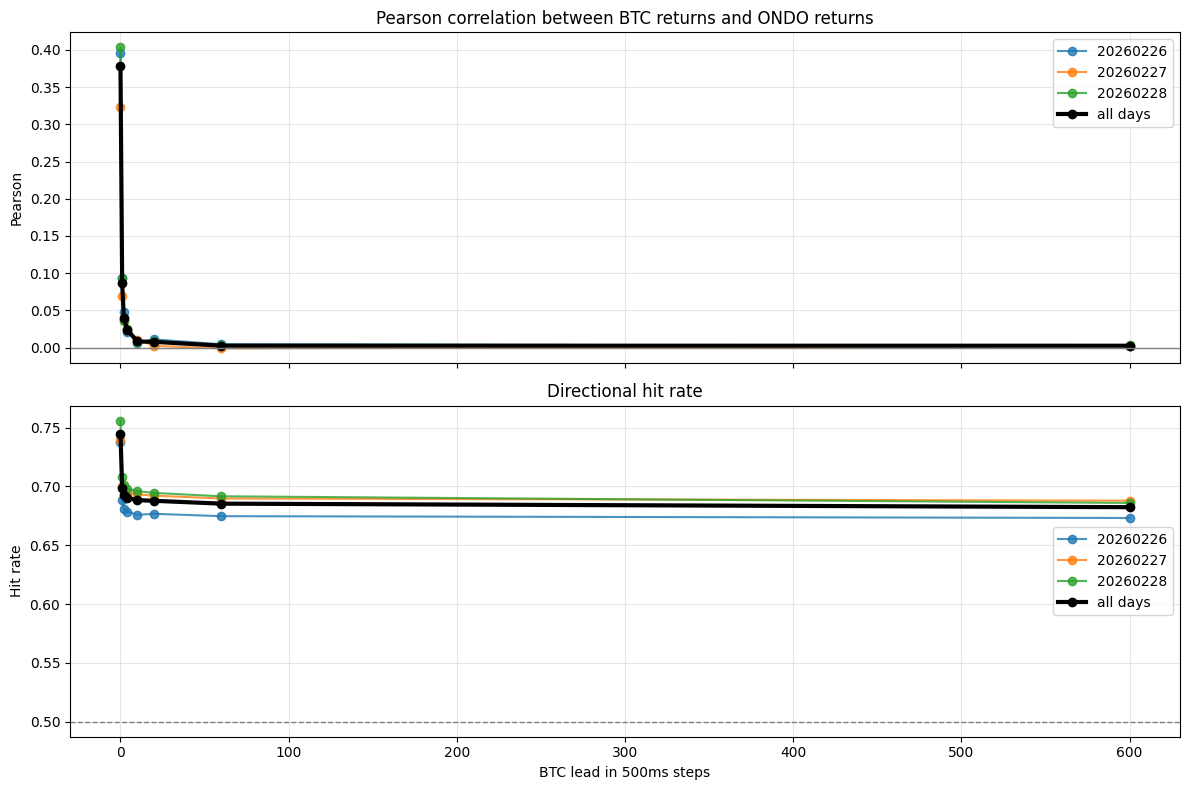

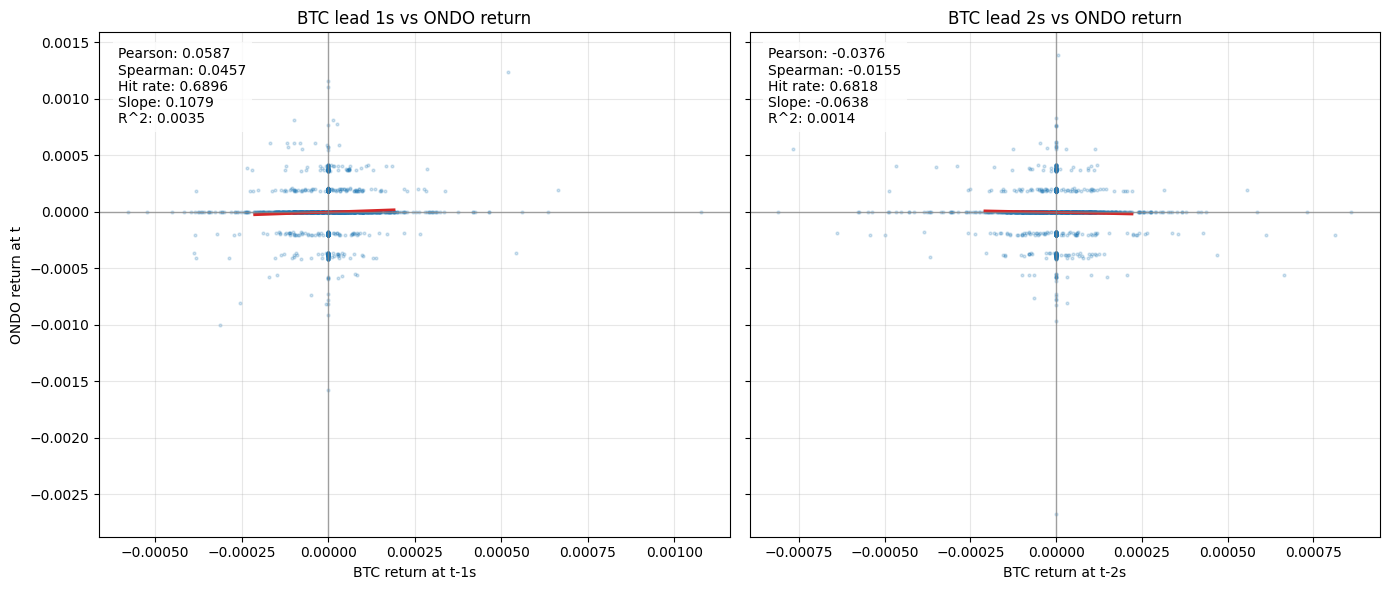

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for day, frame in day_frames.items():
    plot_df = summarize_frame(frame)
    axes[0].plot(plot_df["lag_s"], plot_df["pearson"], marker="o", linewidth=1.5, alpha=0.8, label=day)
    axes[1].plot(plot_df["lag_s"], plot_df["sign_hit"], marker="o", linewidth=1.5, alpha=0.8, label=day)

agg = aggregate_summary.sort_values("lag_s")
axes[0].plot(agg["lag_s"], agg["pearson"], marker="o", linewidth=3.0, color="black", label="all days")
axes[1].plot(agg["lag_s"], agg["sign_hit"], marker="o", linewidth=3.0, color="black", label="all days")

axes[0].axhline(0.0, color="gray", linewidth=1)
axes[1].axhline(0.5, color="gray", linewidth=1, linestyle="--")
axes[0].set_title("Pearson correlation between BTC returns and ONDO returns")
axes[1].set_title("Directional hit rate")
axes[1].set_xlabel("BTC lead in 500ms steps")
axes[0].set_ylabel("Pearson")
axes[1].set_ylabel("Hit rate")
axes[0].legend(loc="best")
axes[1].legend(loc="best")
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

lag_scatter_frames = {
    2: build_aggregate_pair_sample(day_frames, lag_s=2),
    4: build_aggregate_pair_sample(day_frames, lag_s=4),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, lag_s in zip(axes, [2, 4]):
    pair = lag_scatter_frames[lag_s]
    sample = pair.sample(min(len(pair), 5000), random_state=0) if len(pair) else pair
    if sample.empty:
        label = "1s" if lag_s == 2 else "2s"
        ax.set_title(f"BTC lead {label} vs ONDO return")
        ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center", va="center")
        continue

    x = sample["btc_ret_lagged"].to_numpy(dtype=float)
    y = sample["ondo_ret"].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    x_min = float(np.nanpercentile(x, 1))
    x_max = float(np.nanpercentile(x, 99))
    x_line = np.linspace(x_min, x_max, 200)
    pearson = float(sample["btc_ret_lagged"].corr(sample["ondo_ret"]))
    spearman = float(sample["btc_ret_lagged"].corr(sample["ondo_ret"], method="spearman"))
    sign_hit = float((np.sign(x) == np.sign(y)).mean())
    beta = float(slope)
    sse = float(np.sum((y - (slope * x + intercept)) ** 2))
    sst = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - sse / sst if sst > 0 else np.nan

    ax.scatter(x, y, s=4, alpha=0.2)
    ax.plot(x_line, slope * x_line + intercept, color="tab:red", linewidth=2)
    ax.axhline(0.0, color="gray", linewidth=1, alpha=0.7)
    ax.axvline(0.0, color="gray", linewidth=1, alpha=0.7)
    label = "1s" if lag_s == 2 else "2s"
    ax.set_title(f"BTC lead {label} vs ONDO return")
    ax.set_xlabel(f"BTC return at t-{label}")
    ax.grid(True, alpha=0.3)
    ax.text(
        0.03,
        0.97,
        f"Pearson: {pearson:.4f}\nSpearman: {spearman:.4f}\nHit rate: {sign_hit:.4f}\nSlope: {beta:.4f}\nR^2: {r2:.4f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
    )

axes[0].set_ylabel("ONDO return at t")
plt.tight_layout()
plt.show()


## 500ms Lead Check

This repeats the regression view on a 500ms clock grid.

On this grid, `lag_s = 1` means BTC leads ONDO by half a second.
That is the cleanest way to check whether the short-horizon edge survives below the 1s level.


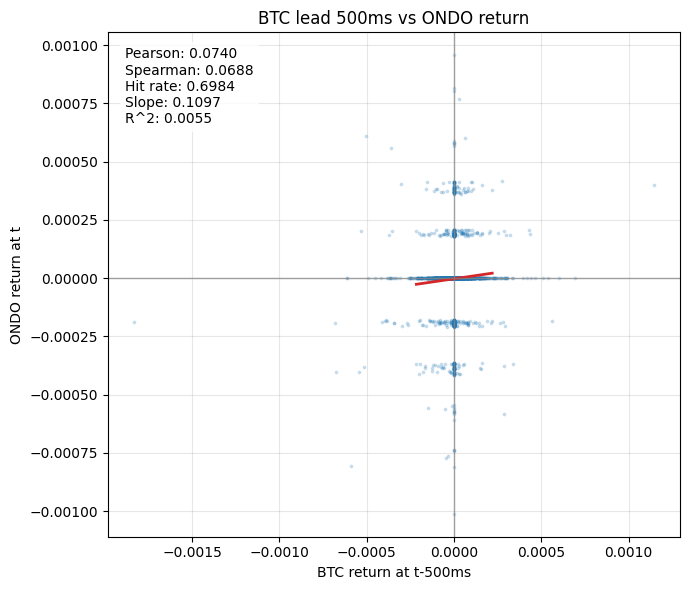

In [7]:
fast_day_frames = {day: build_day_pair_frame(day, grid_freq="500ms") for day in DAYS}
fast_pair = build_aggregate_pair_sample(fast_day_frames, lag_s=1)
fast_sample = fast_pair.sample(min(len(fast_pair), 5000), random_state=0) if len(fast_pair) else fast_pair

fig, ax = plt.subplots(figsize=(7, 6))
if fast_sample.empty:
    ax.set_title("BTC lead 500ms vs ONDO return")
    ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center", va="center")
else:
    x = fast_sample["btc_ret_lagged"].to_numpy(dtype=float)
    y = fast_sample["ondo_ret"].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    x_min = float(np.nanpercentile(x, 1))
    x_max = float(np.nanpercentile(x, 99))
    x_line = np.linspace(x_min, x_max, 200)
    pearson = float(fast_sample["btc_ret_lagged"].corr(fast_sample["ondo_ret"]))
    spearman = float(fast_sample["btc_ret_lagged"].corr(fast_sample["ondo_ret"], method="spearman"))
    sign_hit = float((np.sign(x) == np.sign(y)).mean())
    sse = float(np.sum((y - (slope * x + intercept)) ** 2))
    sst = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - sse / sst if sst > 0 else np.nan

    ax.scatter(x, y, s=3, alpha=0.18)
    ax.plot(x_line, slope * x_line + intercept, color="tab:red", linewidth=2)
    ax.axhline(0.0, color="gray", linewidth=1, alpha=0.7)
    ax.axvline(0.0, color="gray", linewidth=1, alpha=0.7)
    ax.set_title("BTC lead 500ms vs ONDO return")
    ax.set_xlabel("BTC return at t-500ms")
    ax.set_ylabel("ONDO return at t")
    ax.grid(True, alpha=0.3)
    ax.text(
        0.03,
        0.97,
        f"Pearson: {pearson:.4f}\nSpearman: {spearman:.4f}\nHit rate: {sign_hit:.4f}\nSlope: {slope:.4f}\nR^2: {r2:.4f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
    )

plt.tight_layout()
plt.show()


## How To Read The Result

- The `lag_s = 0` row answers the co-movement question.
- The `lag_s = 1` row is the 500ms lead.
- The `lag_s = 2` row is the 1s lead.
- The `lag_s = 4` row is the 2s lead.
- The `lag_s > 0` rows answer the predictive question, with BTC leading ONDO by that many 500ms steps.
- If the correlation and hit rate collapse quickly as lag increases, BTC is mostly moving with ONDO rather than leading it.

For this three-day sample, the notebook is designed to show whether the BTC edge survives beyond the same-second alignment or disappears after a very short delay.


In [8]:
final_view = aggregate_summary.set_index("lag_s")[["pearson", "spearman", "sign_hit", "beta", "r2", "n"]]
display(final_view)

same_time_row = final_view.loc[0]
lead_500ms_row = final_view.loc[1]
lead_1s_row = final_view.loc[2]

print(
    f"Same-time Pearson: {same_time_row['pearson']:.4f} | "
    f"500ms-lead Pearson: {lead_500ms_row['pearson']:.4f} | "
    f"1s-lead Pearson: {lead_1s_row['pearson']:.4f} | "
    f"1s-lead hit rate: {lead_1s_row['sign_hit']:.4f}"
)
print(
    "If the 500ms and 1s lead rows are much weaker than lag 0, BTCUSDC is a co-moving market proxy rather than a strong short-horizon predictor for ONDOUSDC."
)


,pearson,spearman,sign_hit,beta,r2,n
lag_s,,,,,,
0.0,0.378811,0.288262,0.744498,0.676538,0.143498,480521.0
1.0,0.086932,0.063059,0.698862,0.155256,0.007557,480518.0
2.0,0.039538,0.034743,0.692649,0.070613,0.001563,480515.0
4.0,0.024205,0.018234,0.690274,0.043229,0.000585,480509.0
10.0,0.008214,0.005691,0.688317,0.014669,0.000067,480491.0
20.0,0.007684,0.004918,0.687746,0.013724,0.000058,480461.0
60.0,0.002548,0.000649,0.685326,0.004550,0.000006,480341.0
600.0,0.002461,0.002178,0.682316,0.004395,0.000005,478721.0


Same-time Pearson: 0.3788 | 500ms-lead Pearson: 0.0869 | 1s-lead Pearson: 0.0395 | 1s-lead hit rate: 0.6926
If the 500ms and 1s lead rows are much weaker than lag 0, BTCUSDC is a co-moving market proxy rather than a strong short-horizon predictor for ONDOUSDC.


## 2s Train/Validation Regression

This section fits a linear model on `20260226` and `20260227`, then evaluates the same model on `20260228`.

The target is the 2-second ONDO return on the shared 500ms grid, which corresponds to a lag of 4 grid steps.


,split,pearson,spearman,model_spearman,model_hit_rate,model_corr,model_r2,model_mae,n
train,train,0.023265,0.017485,0.017485,0.064171,0.023265,0.000541,0.000035,320345.0
valid,valid,0.025495,0.019638,0.019638,0.069079,0.025495,0.000642,0.000042,160164.0


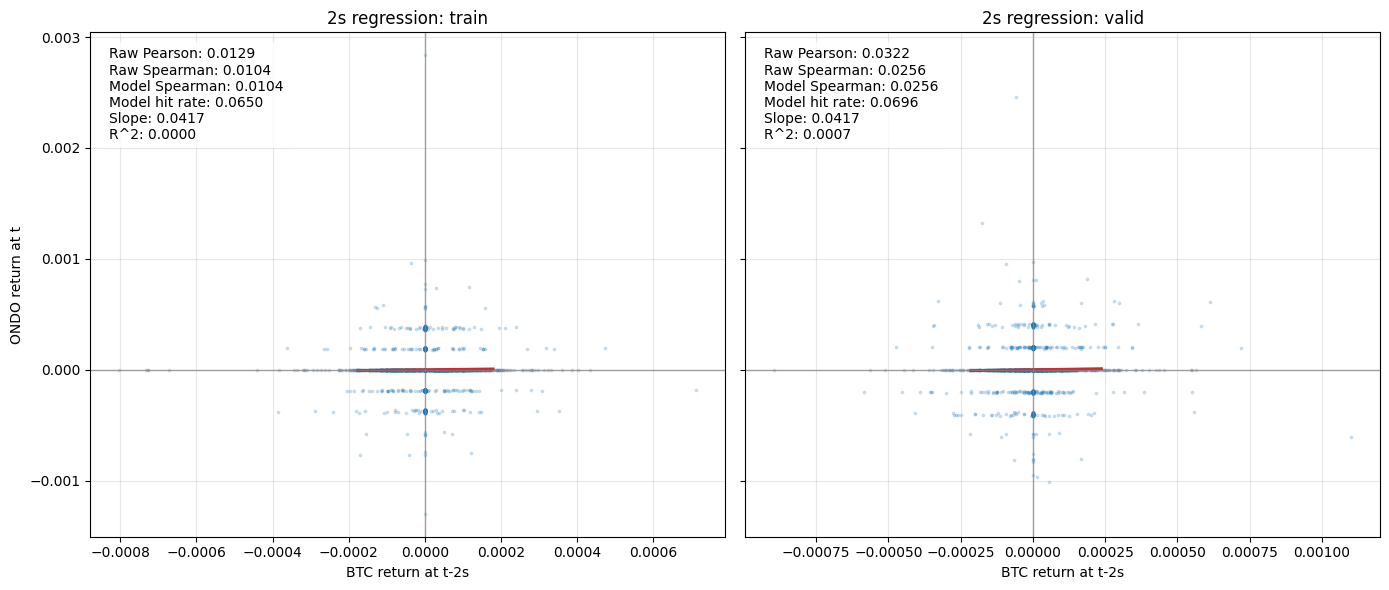

In [9]:
TRAIN_DAYS = ["20260226", "20260227"]
VALID_DAY = "20260228"
PRED_LAG_STEPS = 4  # 2 seconds on the 500ms grid
PRED_LAG_LABEL = "2s"

train_frames = {day: day_frames[day] for day in TRAIN_DAYS}
valid_frames = {VALID_DAY: day_frames[VALID_DAY]}
train_pair = build_aggregate_pair_sample(train_frames, lag_s=PRED_LAG_STEPS)
valid_pair = build_aggregate_pair_sample(valid_frames, lag_s=PRED_LAG_STEPS)

def fit_linear_model(pair: pd.DataFrame) -> tuple[float, float]:
    if pair.empty:
        return np.nan, np.nan
    x = pair["btc_ret_lagged"].to_numpy(dtype=float)
    y = pair["ondo_ret"].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    return float(slope), float(intercept)


def evaluate_split(pair: pd.DataFrame, slope: float, intercept: float) -> pd.Series:
    if pair.empty or not np.isfinite(slope) or not np.isfinite(intercept):
        return pd.Series(
            {
                "pearson": np.nan,
                "spearman": np.nan,
                "model_spearman": np.nan,
                "model_hit_rate": np.nan,
                "model_corr": np.nan,
                "model_r2": np.nan,
                "model_mae": np.nan,
                "n": 0,
            }
        )

    x = pair["btc_ret_lagged"].to_numpy(dtype=float)
    y = pair["ondo_ret"].to_numpy(dtype=float)
    pred = slope * x + intercept
    sse = float(np.sum((y - pred) ** 2))
    sst = float(np.sum((y - y.mean()) ** 2))
    return pd.Series(
        {
            "pearson": float(np.corrcoef(x, y)[0, 1]) if len(pair) > 1 and np.std(x) > 0 and np.std(y) > 0 else np.nan,
            "spearman": float(pair["btc_ret_lagged"].corr(pair["ondo_ret"], method="spearman")),
            "model_spearman": float(pd.Series(pred).corr(pd.Series(y), method="spearman")),
            "model_hit_rate": float((np.sign(pred) == np.sign(y)).mean()),
            "model_corr": float(np.corrcoef(pred, y)[0, 1]) if len(pair) > 1 and np.std(pred) > 0 and np.std(y) > 0 else np.nan,
            "model_r2": 1.0 - sse / sst if sst > 0 else np.nan,
            "model_mae": float(np.mean(np.abs(y - pred))),
            "n": int(len(pair)),
        }
    )


train_slope, train_intercept = fit_linear_model(train_pair)
train_metrics = evaluate_split(train_pair, train_slope, train_intercept).rename("train")
valid_metrics = evaluate_split(valid_pair, train_slope, train_intercept).rename("valid")

split_summary = pd.DataFrame([train_metrics, valid_metrics])
split_summary.insert(0, "split", ["train", "valid"])
split_summary = split_summary[["split", "pearson", "spearman", "model_spearman", "model_hit_rate", "model_corr", "model_r2", "model_mae", "n"]]
display(split_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, (split_name, pair) in zip(axes, [("train", train_pair), ("valid", valid_pair)]):
    sample = pair.sample(min(len(pair), 5000), random_state=0) if len(pair) else pair
    if sample.empty:
        ax.set_title(f"2s regression: {split_name}")
        ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center", va="center")
        continue

    x = sample["btc_ret_lagged"].to_numpy(dtype=float)
    y = sample["ondo_ret"].to_numpy(dtype=float)
    x_min = float(np.nanpercentile(x, 1))
    x_max = float(np.nanpercentile(x, 99))
    x_line = np.linspace(x_min, x_max, 200)
    pred = train_slope * x + train_intercept
    pearson = float(sample["btc_ret_lagged"].corr(sample["ondo_ret"]))
    spearman = float(sample["btc_ret_lagged"].corr(sample["ondo_ret"], method="spearman"))
    model_spearman = float(pd.Series(pred).corr(pd.Series(y), method="spearman"))
    model_hit_rate = float((np.sign(pred) == np.sign(y)).mean())
    sse = float(np.sum((y - (train_slope * x + train_intercept)) ** 2))
    sst = float(np.sum((y - y.mean()) ** 2))
    model_r2 = 1.0 - sse / sst if sst > 0 else np.nan

    ax.scatter(x, y, s=3, alpha=0.18)
    ax.plot(x_line, train_slope * x_line + train_intercept, color="tab:red", linewidth=2)
    ax.axhline(0.0, color="gray", linewidth=1, alpha=0.7)
    ax.axvline(0.0, color="gray", linewidth=1, alpha=0.7)
    ax.set_title(f"2s regression: {split_name}")
    ax.set_xlabel("BTC return at t-2s")
    ax.grid(True, alpha=0.3)
    ax.text(
        0.03,
        0.97,
        f"Raw Pearson: {pearson:.4f}\nRaw Spearman: {spearman:.4f}\nModel Spearman: {model_spearman:.4f}\nModel hit rate: {model_hit_rate:.4f}\nSlope: {train_slope:.4f}\nR^2: {model_r2:.4f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
    )

axes[0].set_ylabel("ONDO return at t")
plt.tight_layout()
plt.show()
